In [1]:
import numpy as np
from scipy.signal import find_peaks
import sys
import os
sys.path.append('/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/utils/')
sys.path.append('/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/bond_based/')

from plot_utils import plot_cluster_size_distribution, analyze_bond_network, plot_rdfs, plot_3d_cluster_with_graph
from bondmodifier_utils import canonical_cluster_workflow, import_file, summarize_bonds

# Import standardized plotting functions
from standardized_plots import (
    plot_coordination_histograms as std_plot_coordination_histograms,
    plot_graph_structure,
    plot_cluster_size_distribution as std_plot_cluster_size_distribution,
    plot_3d_graph_components,
    plot_3d_graph_components_pu_only as std_plot_3d_graph_components_pu_only,
    setup_plot_style,
    get_standard_colors,
    extract_positions_from_data,
    extract_names_from_data,
)

import numpy as np
import networkx as nx


In [2]:


def get_species_densities_from_data(data):
    """
    Calculate species densities from simulation data.
    
    Parameters:
    -----------
    data : OVITO data object
        Simulation data containing particle information
    
    Returns:
    --------
    dict : Dictionary of species densities {species: density}
    """
    import numpy as np
    
    # Get particle types and names
    particle_types = data.particles.particle_types
    type_names = [particle_types.type_by_id(t).name for t in particle_types]
    
    # Get unique species and counts
    unique_species, counts = np.unique(type_names, return_counts=True)
    
    # Calculate box volume from simulation cell
    cell = data.cell
    if cell is not None:
        cell_matrix = cell.matrix
        volume = np.abs(np.linalg.det(cell_matrix[:3, :3]))
    else:
        raise ValueError("Cannot determine box volume from data")
    
    # Calculate densities
    densities = {}
    for species, count in zip(unique_species, counts):
        densities[species] = count / volume
    
    return densities


In [3]:
def calculate_coordination_number(r, g_r, rho_j, r1=None, r2=None):
    """
    Calculate coordination number using the formula:
    CN_ij = 4πρ_j ∫[r1 to r2] r² g_ij(r) dr
    
    Parameters:
    -----------
    r : array
        Radial distances
    g_r : array  
        Radial distribution function values
    rho_j : float
        Number density of species j
    r1, r2 : float, optional
        Integration limits. If None, will be determined automatically.
    
    Returns:
    --------
    float : Coordination number
    """
    
    # Determine integration limits if not provided
    if r1 is None or r2 is None:
        # Find first minimum after first peak using scipy
        # Smooth the data slightly
        smooth_window = 5
        g_smooth = np.convolve(g_r, np.ones(smooth_window)/smooth_window, mode='same')
        
        
        # Invert g(r) to find minima as peaks
        g_inverted = -g_smooth
        
        # Find peaks (minima in original) with prominence filtering
        peaks, _ = find_peaks(g_inverted, prominence=0.5, distance=1)
        
        if len(peaks) > 0:
            # Find first minimum after the first peak
            for peak in peaks:
                r2 = r[peak]
                break
            else:
                r2 = r[-1]
        else:
            r2 = r[-1]
        
        r1 = 0.0
    
    # Ensure integration limits are within data range
    r1 = max(r1, r[0])
    r2 = min(r2, r[-1])
    
    # Find indices for integration
    idx1 = np.argmin(np.abs(r - r1))
    idx2 = np.argmin(np.abs(r - r2))
    
    # Ensure idx1 < idx2
    if idx1 >= idx2:
        idx1 = 0
        idx2 = min(idx1 + 10, len(r) - 1)
    
    # Perform integration
    r_integration = r[idx1:idx2+1]
    g_integration = g_r[idx1:idx2+1]
    
    # Calculate coordination number: CN_ij = 4πρ_j ∫ r² g_ij(r) dr
    integrand = 4 * np.pi * rho_j * r_integration**2 * g_integration
    coordination_number = np.trapz(integrand, r_integration)
    
    return coordination_number

In [5]:
# User inputs
infile = "/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.27/T1100K/dump.lammpstrj"
rdf_samples = 100  # adjust for speed/accuracy

In [6]:
from bond_based.bondmodifier_utils import canonical_cluster_workflow_rdfs_only


pipe = import_file(infile, multiple_frames=True)
print(f"Loaded trajectory with {pipe.source.num_frames} frames")

# Set up standardized plotting style
setup_plot_style()
print("Standardized plotting style configured")

# Still construct all bonds (Voronoi and NaCl) but only cluster Pu atoms
result = canonical_cluster_workflow_rdfs_only(
    pipeline=pipe,
    rdf_samples=rdf_samples
)

r = result["rdf"]
cutoffs = result["pair_cutoffs"]
print("Pairwise cutoffs:", cutoffs)

Loaded trajectory with 14615 frames
Standardized plotting style configured
[-6.22047861e-04 -1.85179690e-03 -5.04266332e-03 -1.26725220e-02
 -2.95524912e-02 -6.41729571e-02 -1.30064551e-01 -2.46488149e-01
 -4.37513877e-01 -7.28563485e-01 -1.14022579e+00 -1.68033362e+00
 -2.33663017e+00 -3.07303600e+00 -3.83180872e+00 -4.54204507e+00
 -5.13253955e+00 -5.54534815e+00 -5.74617663e+00 -5.72897471e+00
 -5.51413581e+00 -5.14162813e+00 -4.66153393e+00 -4.12469059e+00
 -3.57551003e+00 -3.04796920e+00 -2.56464287e+00 -2.13788116e+00
 -1.77200856e+00 -1.46567289e+00 -1.21389816e+00 -1.00974001e+00
 -8.45588439e-01 -7.14118492e-01 -6.08899389e-01 -5.24639952e-01
 -4.57164892e-01 -4.03236113e-01 -3.60311242e-01 -3.26357955e-01
 -2.99715815e-01 -2.79028513e-01 -2.63200899e-01 -2.51354405e-01
 -2.42767041e-01 -2.36823876e-01 -2.33004174e-01 -2.30917485e-01
 -2.30348163e-01 -2.31256643e-01 -2.33715416e-01 -2.37806241e-01
 -2.43531799e-01 -2.50792285e-01 -2.59422371e-01 -2.69264363e-01
 -2.80224877e-0

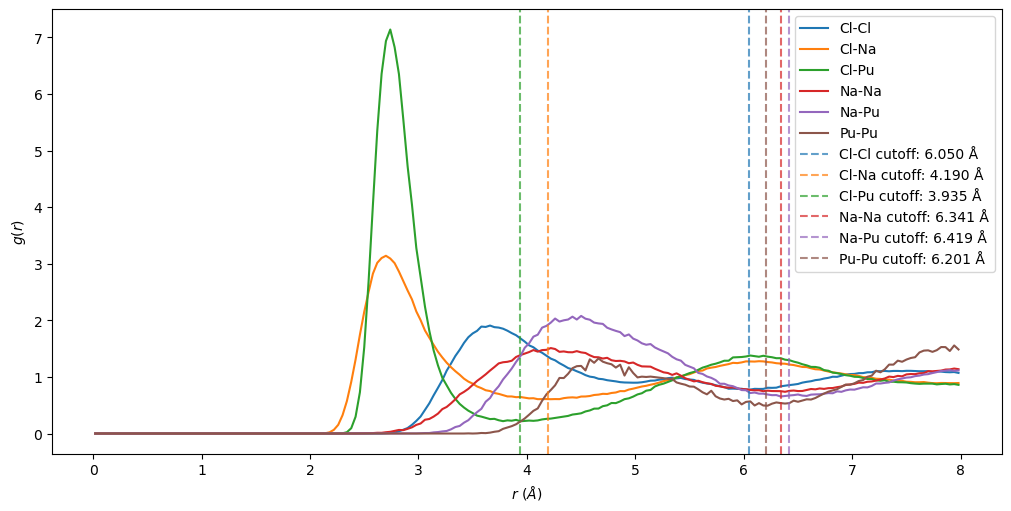

In [7]:
plot_rdfs(result["rdf"], cutoffs=cutoffs,figsize=(10, 5))

In [8]:
def calculate_coordination_number_vs_r(r, g_r, rho_j, r_max=None):
    """
    Calculate coordination number as a function of radial distance r.
    
    This function computes the cumulative coordination number CN(r) by integrating
    the radial distribution function from 0 to r:
    CN(r) = 4πρ_j ∫[0 to r] r'² g_ij(r') dr'
    
    Parameters:
    -----------
    r : array
        Radial distances
    g_r : array  
        Radial distribution function values
    rho_j : float
        Number density of species j
    r_max : float, optional
        Maximum integration distance. If None, uses the full r range.
    
    Returns:
    --------
    tuple : (r_values, cn_values)
        r_values: array of radial distances
        cn_values: array of coordination numbers at each r
    """
    import numpy as np
    
    # Determine integration range
    if r_max is None:
        r_max = r[-1]
    
    # Find the index corresponding to r_max
    r_max_idx = np.argmin(np.abs(r - r_max))
    
    # Use r values up to r_max
    r_values = r[:r_max_idx+1]
    g_values = g_r[:r_max_idx+1]
    
    # Calculate coordination number at each r
    cn_values = np.zeros_like(r_values)
    
    for i in range(len(r_values)):
        # Integrate from 0 to r_values[i]
        r_integration = r_values[:i+1]
        g_integration = g_values[:i+1]
        
        # Calculate integrand: 4πρ_j * r² * g(r)
        integrand = 4 * np.pi * rho_j * r_integration**2 * g_integration
        
        # Perform integration using trapezoidal rule
        cn_values[i] = np.trapz(integrand, r_integration)
    
    return r_values, cn_values


In [ ]:


def plot_multiple_cn_vs_r(cn_data_dict, r_max=None, figsize=(12, 8)):
    """
    Plot multiple coordination number curves on the same figure.
    
    Parameters:
    -----------
    cn_data_dict : dict
        Dictionary with pair names as keys and (r_values, cn_values) tuples as values
    r_max : float, optional
        Maximum r value to plot
    figsize : tuple
        Figure size
    """
    import matplotlib.pyplot as plt
    
    fig, ax = plt.subplots(figsize=figsize)
    
    colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive']
    
    for i, (pair_name, (r_values, cn_values)) in enumerate(cn_data_dict.items()):
        color = colors[i % len(colors)]
        plot_coordination_number_vs_r(r_values, cn_values, pair_name, r_max=r_max, 
                                    ax=ax, color=color, linewidth=2)
    
    ax.set_title('Coordination Number vs Radial Distance (Multiple Pairs)')
    plt.tight_layout()
    plt.show()
    
    return fig, ax


COORDINATION NUMBER AS A FUNCTION OF R
Pu-Cl coordination number at cutoff (3.935 Å): 40.945
R range: 0.020 to 7.980 Å
Number of points: 200


/tmp/ipykernel_656748/1787466056.py:51: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  cn_values[i] = np.trapz(integrand, r_integration)


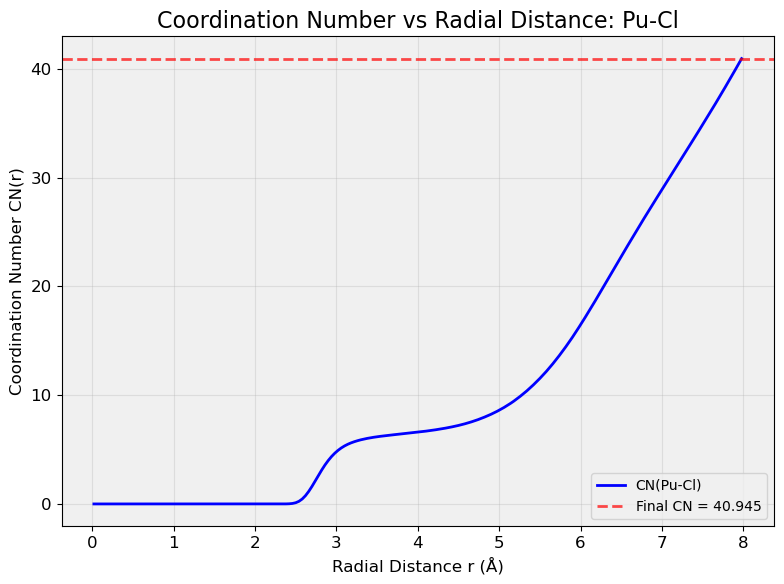

In [19]:
# Example: Calculate CN(r) for Pu-Cl pair using current data
print("=" * 60)
print("COORDINATION NUMBER AS A FUNCTION OF R")
print("=" * 60)

# Get current data
current_rdf = result["rdf"]
current_cutoffs = result["pair_cutoffs"]
current_densities = get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))

rmax=10.0
# Calculate CN(r) for Pu-Cl pair
r_pucl, cn_pucl = calculate_coordination_number_vs_r(
    current_rdf["r"], 
    current_rdf["Cl-Pu"], 
    current_densities["Cl"],
    r_max=rmax
)

print(f"Pu-Cl coordination number at cutoff ({current_cutoffs[('Pu', 'Cl')]:.3f} Å): {cn_pucl[-1]:.3f}")
print(f"R range: {r_pucl[0]:.3f} to {r_pucl[-1]:.3f} Å")
print(f"Number of points: {len(r_pucl)}")

# Plot the result
ax=plot_coordination_number_vs_r(r_pucl, cn_pucl, "Pu-Cl", r_max=rmax)


In [20]:
r_pucl

array([0.02, 0.06, 0.1 , 0.14, 0.18, 0.22, 0.26, 0.3 , 0.34, 0.38, 0.42,
       0.46, 0.5 , 0.54, 0.58, 0.62, 0.66, 0.7 , 0.74, 0.78, 0.82, 0.86,
       0.9 , 0.94, 0.98, 1.02, 1.06, 1.1 , 1.14, 1.18, 1.22, 1.26, 1.3 ,
       1.34, 1.38, 1.42, 1.46, 1.5 , 1.54, 1.58, 1.62, 1.66, 1.7 , 1.74,
       1.78, 1.82, 1.86, 1.9 , 1.94, 1.98, 2.02, 2.06, 2.1 , 2.14, 2.18,
       2.22, 2.26, 2.3 , 2.34, 2.38, 2.42, 2.46, 2.5 , 2.54, 2.58, 2.62,
       2.66, 2.7 , 2.74, 2.78, 2.82, 2.86, 2.9 , 2.94, 2.98, 3.02, 3.06,
       3.1 , 3.14, 3.18, 3.22, 3.26, 3.3 , 3.34, 3.38, 3.42, 3.46, 3.5 ,
       3.54, 3.58, 3.62, 3.66, 3.7 , 3.74, 3.78, 3.82, 3.86, 3.9 , 3.94,
       3.98, 4.02, 4.06, 4.1 , 4.14, 4.18, 4.22, 4.26, 4.3 , 4.34, 4.38,
       4.42, 4.46, 4.5 , 4.54, 4.58, 4.62, 4.66, 4.7 , 4.74, 4.78, 4.82,
       4.86, 4.9 , 4.94, 4.98, 5.02, 5.06, 5.1 , 5.14, 5.18, 5.22, 5.26,
       5.3 , 5.34, 5.38, 5.42, 5.46, 5.5 , 5.54, 5.58, 5.62, 5.66, 5.7 ,
       5.74, 5.78, 5.82, 5.86, 5.9 , 5.94, 5.98, 6.

In [21]:
cn_pucl

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
      

In [23]:
from bond_based.bondmodifier_utils import gaussian_smooth, find_first_shell_minimum

In [24]:


# Helper function for proper shell detection
def detect_proper_shells(first_deriv, min_prominence=0.1, smoothing_method='gaussian', gaussian_sigma=3.0):
    """
    Detect shells using proper pattern: derivative goes up, peaks, then goes down to zero.
    
    Args:
        first_deriv: First derivative array
        min_prominence: Minimum prominence for peaks
        
    Returns:
        Array of shell boundary indices
    """
    # Find peaks in first derivative (where coordination growth is fastest)
    if smoothing_method == 'gaussian':
        first_deriv = gaussian_smooth(first_deriv, gaussian_sigma, mode='nearest')
    else:
        raise ValueError(f"Unknown smoothing method: {smoothing_method}. Choose from: 'moving_avg', 'savgol', 'gaussian'")
        
    peaks, properties = find_peaks(first_deriv, prominence=min_prominence, distance=10)
    
    if len(peaks) == 0:
        return np.array([])
    
    # For each peak, find the subsequent minimum (where derivative goes to zero)
    shell_boundaries = []
    
    for peak_idx in peaks:
        # Look for minima after this peak
        search_start = peak_idx + 5  # Start searching a bit after the peak
        search_end = min(peak_idx + 50, len(first_deriv))  # Don't search too far
        
        if search_start >= len(first_deriv):
            continue
            
        # Find minima in the region after the peak
        region_deriv = first_deriv[search_start:search_end]
        if len(region_deriv) < 5:
            continue
            
        # Look for points where derivative is close to zero (plateau)
        zero_threshold = np.std(first_deriv) * 0.2
        zero_crossings = np.where(np.abs(region_deriv) < zero_threshold)[0]
        
        if len(zero_crossings) > 0:
            # Take the first significant zero crossing after the peak
            shell_idx = search_start + zero_crossings[0]
            shell_boundaries.append(shell_idx)
    
    return np.array(shell_boundaries)


In [ ]:
def shell_cutoffs(r, cn, shell_boundaries):
    """
    Calculate shell cutoffs based on coordination number and radial distance.
    
    Args:
        r: Radial distance array


In [25]:
first_deriv = np.gradient(cn_pucl, r_pucl)

In [27]:
detect_proper_shells(first_deriv)

array([89])

In [34]:
current_rdf["r"][89]

np.float64(3.58)